# Capstone Function 6
You’re optimising a cake recipe using a black-box function with five ingredient inputs, for example flour, sugar, eggs, butter and milk. Each recipe is evaluated with a combined score based on flavour, consistency, calories, waste and cost, where each factor contributes negative points as judged by an expert taster. This means the total score is negative by design. 

To frame this as a maximisation problem, your goal is to bring that score as close to zero as possible or, equivalently, to maximise the negative of the total sum.

 Input | Output | Goal |
|-------|--------|------|
| 5D Array (20, 5) | 1D Array (20, ) | Maximise |

# Exploratory Data Analysis

In [1]:
# load and view a .npy file
import numpy as np
from matplotlib import pyplot as plt
import sys
# load the .npy file
initial_inputs = np.load("data/initial_inputs.npy")
initial_outputs = np.load("data/initial_outputs.npy")
# summarize shape
print(initial_inputs.shape)
print(initial_outputs.shape)

# create a dataframe from inputs and outputs
import pandas as pd
data = pd.DataFrame(initial_inputs, columns=[f'input_{i}' for i in range(initial_inputs.shape[1])])
data['output'] = initial_outputs
print(data.head(20))

# save the data as a CSV file
data.to_csv("data/initial_data.csv", index=False)

(20, 5)
(20,)
     input_0   input_1   input_2   input_3   input_4    output
0   0.728186  0.154693  0.732552  0.693997  0.056401 -0.714265
1   0.242384  0.844100  0.577809  0.679021  0.501953 -1.209955
2   0.729523  0.748106  0.679775  0.356552  0.671054 -1.672200
3   0.770620  0.114404  0.046780  0.648324  0.273549 -1.536058
4   0.618812  0.331802  0.187288  0.756238  0.328835 -0.829237
5   0.784958  0.910682  0.708120  0.959225  0.004911 -1.247049
6   0.145111  0.896685  0.896322  0.726272  0.236272 -1.233786
7   0.945069  0.288459  0.978806  0.961656  0.598016 -1.694343
8   0.125720  0.862725  0.028544  0.246605  0.751206 -2.571170
9   0.757594  0.355831  0.016523  0.434207  0.112433 -1.309116
10  0.536797  0.308781  0.411879  0.388225  0.522528 -1.144785
11  0.957740  0.235669  0.099146  0.156806  0.071317 -1.912677
12  0.629308  0.803484  0.811408  0.045613  0.110624 -1.622839
13  0.021735  0.428084  0.835939  0.489489  0.511082 -1.356682
14  0.439344  0.698924  0.426820  0.10947

## Observations


# Gaussian Process with EI, PI and UCB

Next sample based on UCB: [0.35353535 0.5        0.5        0.5        0.5       ]
Next sample based on EI: [0.34343434 0.5        0.5        0.5        0.5       ]
Next sample based on PI: [0.35353535 0.5        0.5        0.5        0.5       ]


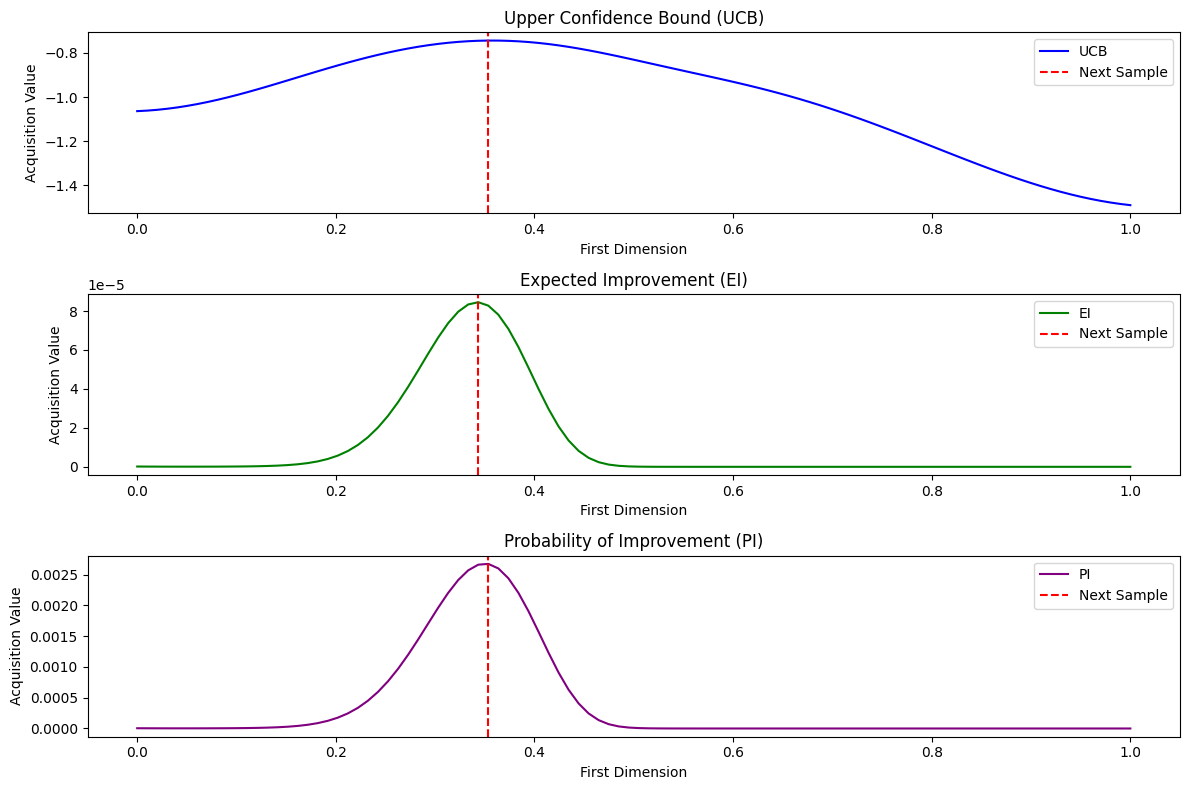

In [4]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm

def fit_gp(X, y):
    """
    Fit a Gaussian Process with ARD RBF kernel on 4D inputs.
    Assumes X is scaled to [0,1]^4 (recommended).
    """
    kernel = C(1.0, (1e-3, 1e3)) * RBF(
        length_scale=[0.3, 0.3, 0.3, 0.3, 0.3],
        length_scale_bounds=(1e-2, 1e2)
    )
    gp = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=5,
        alpha=1e-4,          # small noise term; tune for your data
        normalize_y=True
    )
    gp.fit(X, y)
    return gp

# Load the dataset
X = np.load("initial_inputs.npy")
y = np.load("initial_outputs.npy")

gp = fit_gp(X, y)

# Generate candidate points for visualization (fix 4 dimensions, vary 1 dimension)
n_candidates = 100
X_candidates = np.zeros((n_candidates, 5))
X_candidates[:, 0] = np.linspace(0, 1, n_candidates)  # vary first dimension
X_candidates[:, 1:] = 0.5  # fix others at 0.5

# Predict mean and standard deviation for candidates
mu, sigma = gp.predict(X_candidates, return_std=True)

# Best observed value
y_best = np.max(y)

# Acquisition functions
def UCB(mu, sigma, kappa=2.5):
    return mu + kappa * sigma

def EI(mu, sigma, y_best):
    improvement = mu - y_best
    Z = improvement / sigma
    return (improvement * norm.cdf(Z) + sigma * norm.pdf(Z))

def PI(mu, sigma, y_best):
    Z = (mu - y_best) / sigma
    return norm.cdf(Z)

ucb_values = UCB(mu, sigma)
ei_values = EI(mu, sigma, y_best)
pi_values = PI(mu, sigma, y_best)

# Select next sample for each acquisition function
next_ucb = X_candidates[np.argmax(ucb_values)]
next_ei = X_candidates[np.argmax(ei_values)]
next_pi = X_candidates[np.argmax(pi_values)]

print("Next sample based on UCB:", next_ucb)
print("Next sample based on EI:", next_ei)
print("Next sample based on PI:", next_pi)

# Visualization of acquisition functions
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(X_candidates[:, 0], ucb_values, label='UCB', color='blue')
plt.title('Upper Confidence Bound (UCB)')
plt.xlabel('First Dimension')
plt.ylabel('Acquisition Value')
plt.axvline(next_ucb[0], color='red', linestyle='--', label='Next Sample')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(X_candidates[:, 0], ei_values, label='EI', color='green')
plt.title('Expected Improvement (EI)')
plt.xlabel('First Dimension')
plt.ylabel('Acquisition Value')
plt.axvline(next_ei[0], color='red', linestyle='--', label='Next Sample')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(X_candidates[:, 0], pi_values, label='PI', color='purple')
plt.title('Probability of Improvement (PI)')
plt.xlabel('First Dimension')
plt.ylabel('Acquisition Value')
plt.axvline(next_pi[0], color='red', linestyle='--', label='Next Sample')
plt.legend()

plt.tight_layout()
plt.show()


In [5]:
random_numbers = [np.random.random() for _ in range(6)]
print(random_numbers)

[0.5077287964287477, 0.3826373790755797, 0.45499390164636544, 0.37412641399109225, 0.825804128246081, 0.9273054767462718]


# Week 1 Submission
0.507728-0.382637-0.454993-0.374126-0.825804

---
---
# Week 2
Try to improve the process:
1. Build a SMBO (Sequential Model Based Optimisation) process to iteratively add new samples as they become available.
2. Visualize the performance - convergence
3. True to improve the various parameters!
4. Review which acquisition function to use

Suggested new points: [[0.5709119270346998, 0.2861111191298491, 0.6191128345959707, 0.8802809964491485, 0.0]]


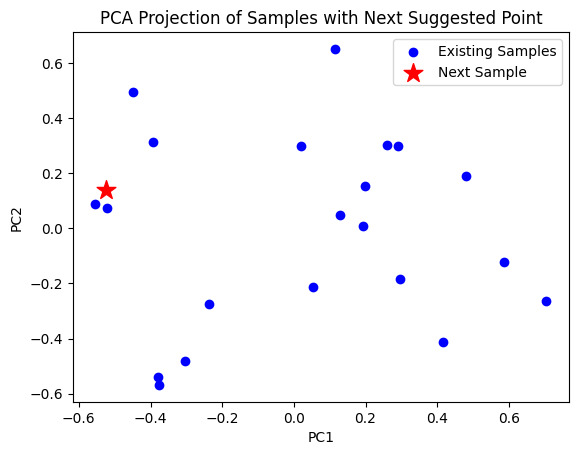

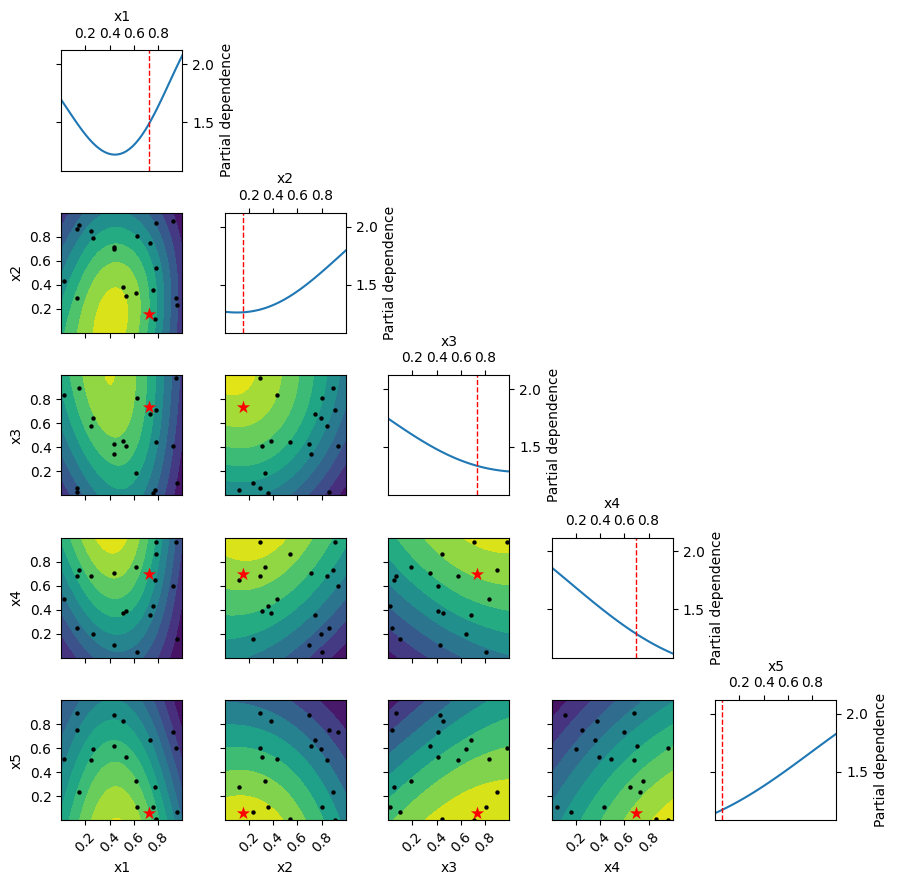

In [5]:

from skopt import Optimizer
from skopt.plots import plot_objective
from skopt.space import Real
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Define search space
space = [Real(0.0, 1.0, name='x1'),
         Real(0.0, 1.0, name='x2'),
         Real(0.0, 1.0, name='x3'),
         Real(0.0, 1.0, name='x4'),
         Real(0.0, 1.0, name='x5')]

# 2. Create Optimizer
opt = Optimizer(dimensions=space, base_estimator="GP", acq_func="PI", random_state=42)

# 3. Existing data (10 samples)
X = np.load("data/initial_inputs.npy").tolist()
y = np.load("data/initial_outputs.npy").tolist()

# insert a new observation at end of X and y (negate y for maximisation)
X.append([0.507728, 0.382637, 0.454993, 0.374126, 0.825804])
y.append(-1.445052)

# negate the y values for maximisation
y = [-val for val in y]

# 4. Seed the optimiser
res = opt.tell(X, y)

# 5. Ask for new candidate points (no objective function needed)
next_points = opt.ask(n_points=1)  # propose new point
print("Suggested new points:", next_points)

# Use PCA to plot the next sample in 2D
pca = PCA(n_components=2)
proj = pca.fit_transform(np.array(X + next_points))
plt.scatter(proj[:-1, 0], proj[:-1, 1], c='blue', label='Existing Samples')
plt.scatter(proj[-1, 0], proj[-1, 1], c='red', label='Next Sample', marker='*', s=200)
plt.title('PCA Projection of Samples with Next Suggested Point')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

_ = plot_objective(res)


## Submission
0.570911-0.286111-0.619112-0.880280-0.000000

---
---
# Week 3

Suggested new points: 0.383069-0.000000-0.865257-1.000000-0.000000


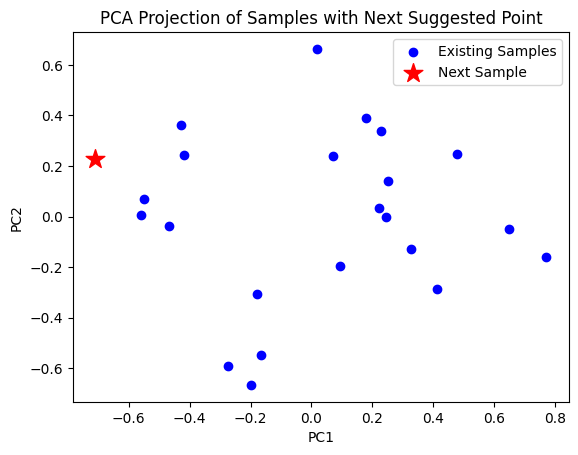

00. X: 0.728186, 0.154693, 0.732552, 0.693997, 0.056401, y:       -0.714265
01. X: 0.242384, 0.844100, 0.577809, 0.679021, 0.501953, y:       -1.209955
02. X: 0.729523, 0.748106, 0.679775, 0.356552, 0.671054, y:       -1.672200
03. X: 0.770620, 0.114404, 0.046780, 0.648324, 0.273549, y:       -1.536058
04. X: 0.618812, 0.331802, 0.187288, 0.756238, 0.328835, y:       -0.829237
05. X: 0.784958, 0.910682, 0.708120, 0.959225, 0.004911, y:       -1.247049
06. X: 0.145111, 0.896685, 0.896322, 0.726272, 0.236272, y:       -1.233786
07. X: 0.945069, 0.288459, 0.978806, 0.961656, 0.598016, y:       -1.694343
08. X: 0.125720, 0.862725, 0.028544, 0.246605, 0.751206, y:       -2.571170
09. X: 0.757594, 0.355831, 0.016523, 0.434207, 0.112433, y:       -1.309116
10. X: 0.536797, 0.308781, 0.411879, 0.388225, 0.522528, y:       -1.144785
11. X: 0.957740, 0.235669, 0.099146, 0.156806, 0.071317, y:       -1.912677
12. X: 0.629308, 0.803484, 0.811408, 0.045613, 0.110624, y:       -1.622839
13. X: 0.021

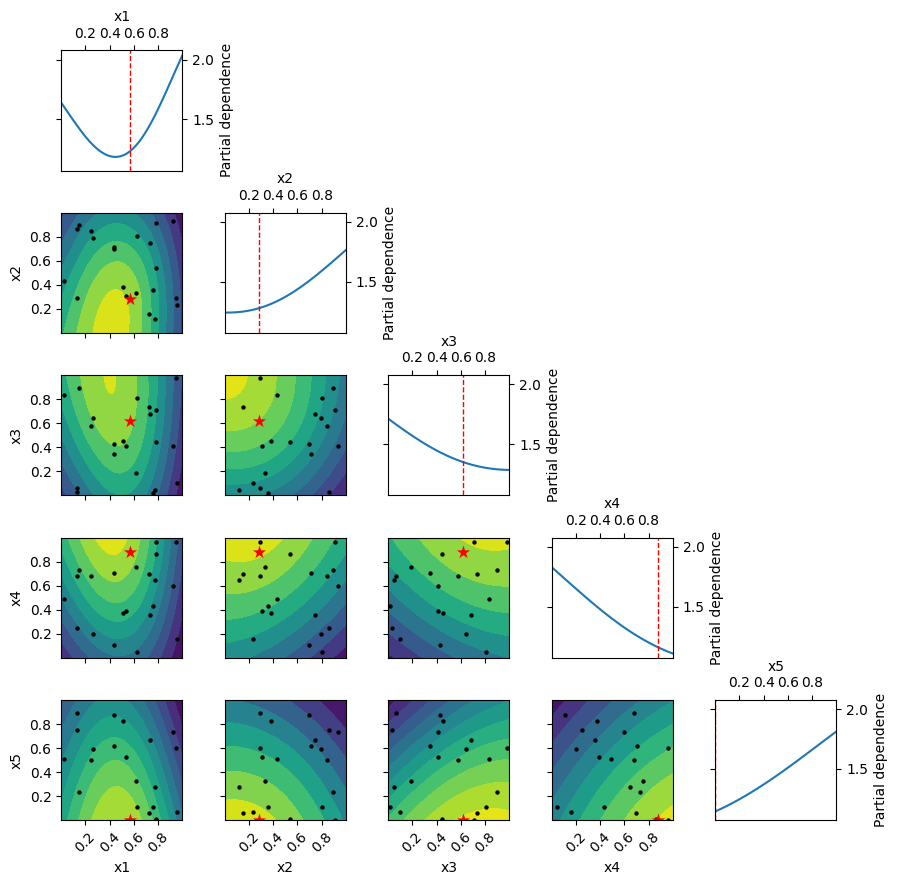

In [8]:

from skopt import Optimizer
from skopt.plots import plot_objective
from skopt.space import Real
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# 1. Define search space
space = [Real(0.0, 1.0, name='x1'),
         Real(0.0, 1.0, name='x2'),
         Real(0.0, 1.0, name='x3'),
         Real(0.0, 1.0, name='x4'),
         Real(0.0, 1.0, name='x5')]

# 2. Create Optimizer
opt = Optimizer(dimensions=space, base_estimator="GP", acq_func="EI", random_state=42, acq_func_kwargs={'xi': 0.0})

# 3. Existing data (10 samples)
X = np.load("data/initial_inputs.npy").tolist()
y = np.load("data/initial_outputs.npy").tolist()

# insert a new observation Week 1
X.append([0.507728, 0.382637, 0.454993, 0.374126, 0.825804])
y.append(-1.445052)

# insert a new observation Week 2
X.append([0.570911, 0.286111, 0.619112, 0.880280, 0.000000])
y.append(-0.454129)

# negate the y values for maximisation
y = [-val for val in y]

# 4. Seed the optimiser
res = opt.tell(X, y)

# 5. Ask for new candidate points (no objective function needed)
next_point = opt.ask(n_points=1)  # propose new point
print(f"Suggested new points: {next_point[0][0]:.6f}-{next_point[0][1]:.6f}-{next_point[0][2]:.6f}-{next_point[0][3]:.6f}-{next_point[0][4]:.6f}")

# Use PCA to plot the next sample in 2D
pca = PCA(n_components=2)
proj = pca.fit_transform(np.array(X + next_point))
plt.scatter(proj[:-1, 0], proj[:-1, 1], c='blue', label='Existing Samples')
plt.scatter(proj[-1, 0], proj[-1, 1], c='red', label='Next Sample', marker='*', s=200)
plt.title('PCA Projection of Samples with Next Suggested Point')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

_ = plot_objective(res)

# negate all the y values back to original
y = [-val for val in y]

# Print X and y in a formatted way with unpacked coordinates
max_y_index = np.argmax(y)
# Use fixed width for y column (easier to read)
for i in range(len(X)):
    x_str = ", ".join(f"{val:.6f}" for val in X[i])
    
    # Right-align y values in 15 character width
    y_str = f"{y[i]:>15.6f}"
    
    if i == max_y_index:
        print(f"{i:02d}. \033[92mX: {x_str}, y: {y_str}\033[0m")
    else:
        print(f"{i:02d}. X: {x_str}, y: {y_str}")



---
---
# Week 4

### Hyperparameter Selection - signficant convergence in last samples - exploit
- acquisition function = EI
- xi = 0

Suggested new point: 0.528391-0.388505-0.378203-1.000000-0.000000


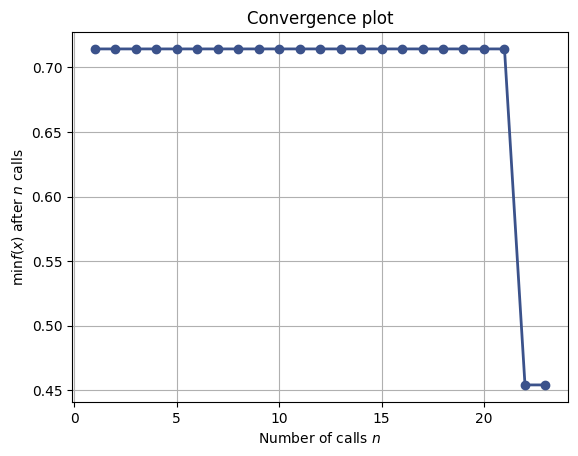

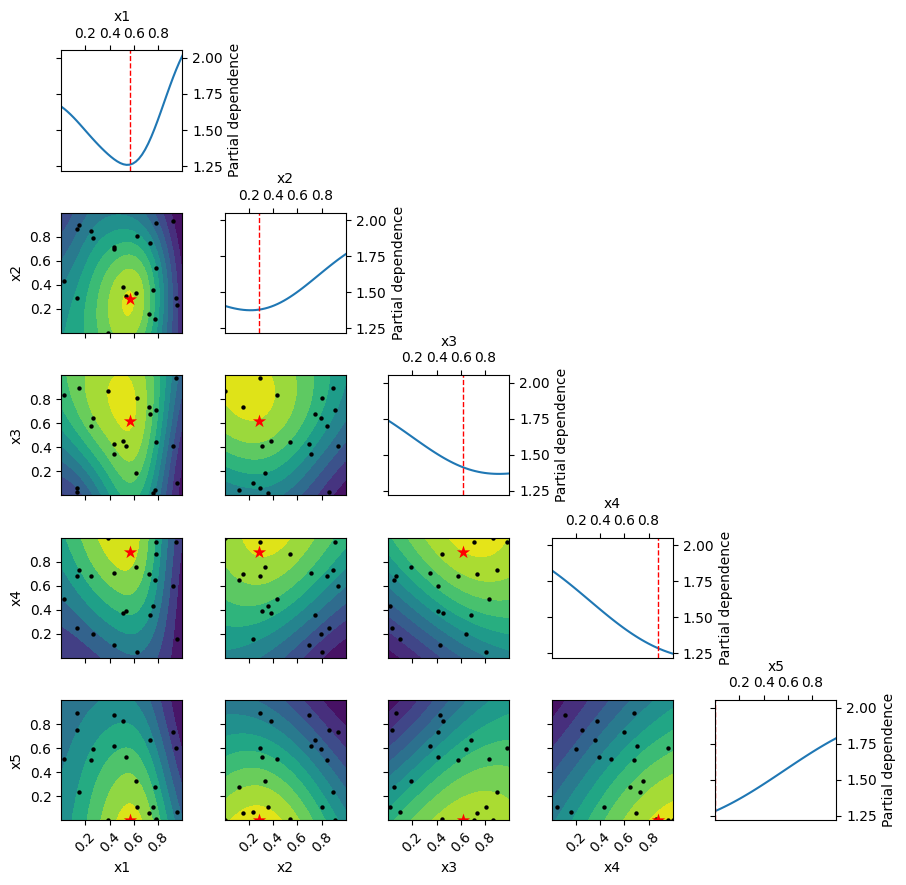

In [3]:
from skopt import Optimizer
from skopt.plots import plot_objective, plot_convergence
from skopt.space import Real
import numpy as np

# 1. Define search space
space = [Real(0.0, 1.0, name='x1'),
         Real(0.0, 1.0, name='x2'),
         Real(0.0, 1.0, name='x3'),
         Real(0.0, 1.0, name='x4'),
         Real(0.0, 1.0, name='x5')]

# set the hyperparameters for Optimizer
base_estimator = "GP"
acq_func = "EI"
random_state = 42
acq_func_kwargs = {'xi': 0.0}

# 2. Create Optimizer
opt = Optimizer(dimensions=space, base_estimator=base_estimator, acq_func=acq_func, random_state=random_state, acq_func_kwargs=acq_func_kwargs)

# 3. Existing data ()
X = np.load("../data/f6/updated_inputs.npy").tolist()
y = np.load("../data/f6/updated_outputs.npy").tolist()

# negate the y values for maximisation
y = [-val for val in y]

# 4. Seed the optimiser
res = opt.tell(X, y)

# 5. Ask for new candidate points (no objective function needed)
next_point = opt.ask(n_points=1)  # propose next point
print(f"Suggested new point: {next_point[0][0]:.6f}-{next_point[0][1]:.6f}-{next_point[0][2]:.6f}-{next_point[0][3]:.6f}-{next_point[0][4]:.6f}")

# plot the convergence
__ = plot_convergence(res)

# plot the objective function
_ = plot_objective(res)




---
---
# Week 5

### Hyperparameter Selection - signficant convergence in last samples - exploit
- acquisition function = EI
- xi = 0

Suggested new point: 0.586039-0.350833-0.813401-0.765164-0.000000


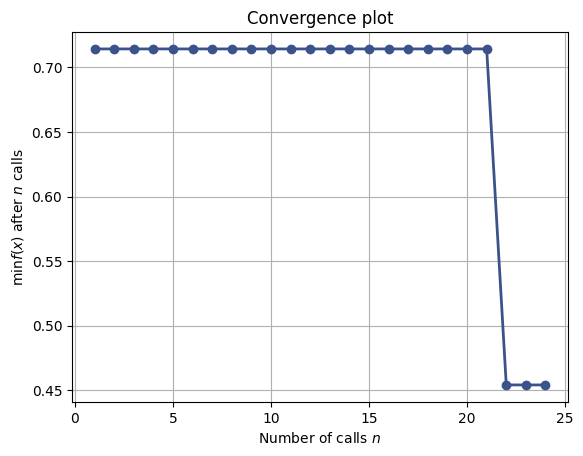

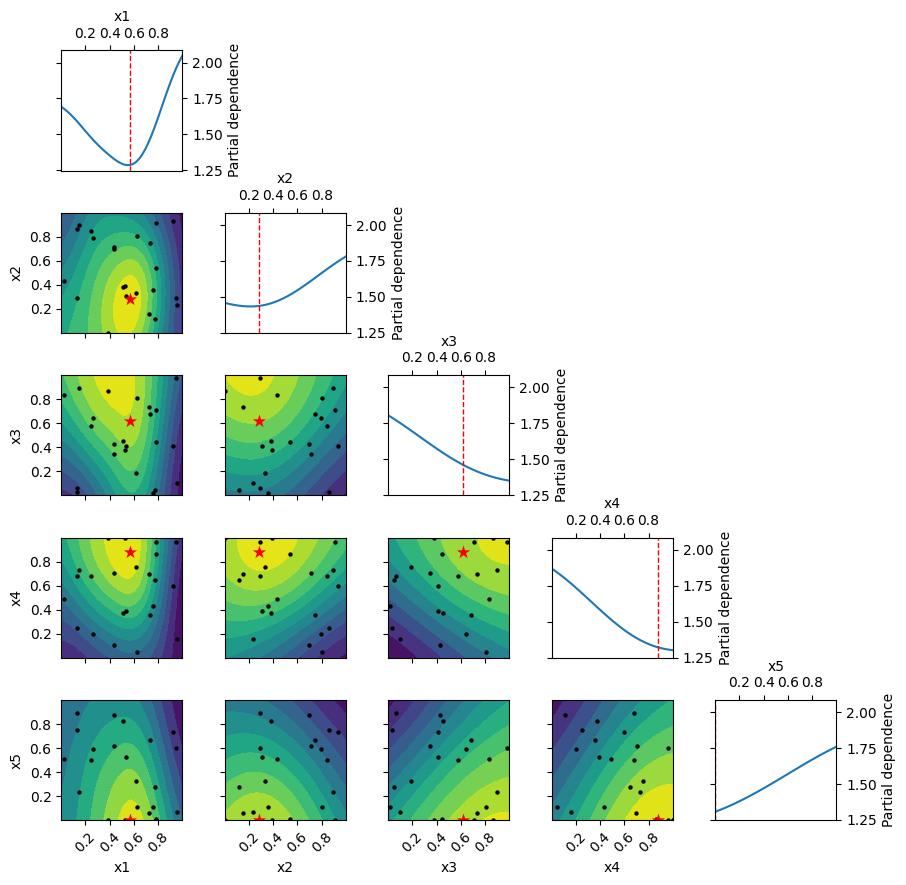

In [4]:
from skopt import Optimizer
from skopt.plots import plot_objective, plot_convergence
from skopt.space import Real
import numpy as np

# 1. Define search space
space = [Real(0.0, 1.0, name='x1'),
         Real(0.0, 1.0, name='x2'),
         Real(0.0, 1.0, name='x3'),
         Real(0.0, 1.0, name='x4'),
         Real(0.0, 1.0, name='x5')]

# set the hyperparameters for Optimizer
base_estimator = "GP"
acq_func = "EI"
random_state = 42
acq_func_kwargs = {'xi': 0.0}

# 2. Create Optimizer
opt = Optimizer(dimensions=space, base_estimator=base_estimator, acq_func=acq_func, random_state=random_state, acq_func_kwargs=acq_func_kwargs)

# 3. Existing data ()
X = np.load("../data/f6/updated_inputs - Week 4.npy").tolist()
y = np.load("../data/f6/updated_outputs - Week 4.npy").tolist()

# negate the y values for maximisation
y = [-val for val in y]

# 4. Seed the optimiser
res = opt.tell(X, y)

# 5. Ask for new candidate points (no objective function needed)
next_point = opt.ask(n_points=1)  # propose next point
print(f"Suggested new point: {next_point[0][0]:.6f}-{next_point[0][1]:.6f}-{next_point[0][2]:.6f}-{next_point[0][3]:.6f}-{next_point[0][4]:.6f}")

# plot the convergence
__ = plot_convergence(res)

# plot the objective function
_ = plot_objective(res)


